# Valentina Garcia's Capstone project

This code is for Valentina Garcia's capstone project for the Professional Certificate in Machine Learning and Artificial Intelligance
program offered by UC Berkeley. 

In this project we will be examining analyzed proteomics data that was published as part of this paper: doi: 10.1186/s13068-026-02750-w.
In this data there is the percent protein abundace of endogenous and exogenous genes expressed in Rhodosporidium toruloides. Some of these 
samples have been transformed through lithium acetate, agrobactium mediated transformation, or both. Included with these samples is non-transformed controls. 

First this code generates classification models for predicting which populations are engineered by what method. I will start by generating an n-nearest neighbors model, a random forest classifier, and a decision tree classifier. We will next do an extensive paramater search for the random forest classifier. We will use accuarcy scores and confusion matrixes to evaluate how the models are performing at identifying the different data types.  

Next this code generates models for predicting exogenous protein expression based on the protein expression of endogenous genes. I evaluate a linear regression, Lasso, and Elastic models for the prediction and perform a lasso model with a more optimal alpha score. Models will be 
evaluated by the mean squared error along with a scatter plot show the actual and predicted values for the test set. The scatter plot will also report the R-squared value.


In [1]:
#Importing the required imports

import re
import zipfile
from pathlib import Path

# Data Analysis & Plotting
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Scikit-Learn: Data Preprocessing & Selection
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

# Scikit-Learn: Models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression, ElasticNetCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text

# Scikit-Learn: Model Selection & Hyperparameter Tuning
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)

# Scikit-Learn: Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    ConfusionMatrixDisplay
)

## Data Ingestion, Cleaning, and Restructuring
At the end of this section will have two sets of data one containing all of the proteins measured and another just containing the endogenous R. toruloides proteins. For both some meta data will be included including the methadology for strain engineering or if there was no engineering.

In [2]:
#Data Ingestion
# Unzips the folder
with zipfile.ZipFile("data.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

folder_path = Path("data")
df_list = []

# Extracts data from the CSV files in the zipped folder into a pandas dataframe
csv_files = [f for f in folder_path.rglob("*.csv") if not f.name.startswith("._")]

for index, file in enumerate(csv_files, start=1):
    print(f"[{index}/{len(csv_files)}] Reading: {file.name}")
    temp_df = pd.read_csv(file)
    temp_df.insert(0, "source_file", file.name)
    df_list.append(temp_df)
    
if df_list:
    all_files_raw_df = pd.concat(df_list, ignore_index=True)
    print(f"\nDone! Combined {len(df_list)} CSV files into a DataFrame with {len(all_files_raw_df):,} total rows.")
else:
    print("No valid CSV files found to combine.")



[1/5] Reading: pPA212V1_Top3_Full_list_proteins_summary_20241002-162152.csv
[2/5] Reading: pPA212Top3_Full_list_proteins_summary_20250114-022452.csv
[3/5] Reading: pPA218Top3_Full_list_proteins_summary_20250115-063057.csv
[4/5] Reading: Top3_Full_list_proteins_summary_20241002-162152.csv
[5/5] Reading: pPA212V1pVEG23Top3_Full_list_proteins_summary_20241002-162152.csv

Done! Combined 5 CSV files into a DataFrame with 2,313,640 total rows.


In [3]:
#Looking at and evalutating the dataframe
# Display the first few rows
all_files_raw_df.head()


,source_file,Protein.Group,Protein.Names,Protein,Protein.Description,Sample,Top_3pep_counts_rep_mean,Top_3pep_counts_rep_std,%_of protein_abundance_Top3_rep_mean,%_of protein_abundance_Top3-rep_std,log10_%_abundance_rep_mean,log10_%_abundance_rep_std,CV%_of_%_protein_abundance,%_of protein_abundance_Top3_rep_mean_sem,Sample_size,Z-score
0,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_144h_R1,2488882.000,NaN,0.190514,NaN,-0.720073,NaN,NaN,0.001897,310,0.571640
1,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_144h_R2,2606241.333,NaN,0.203287,NaN,-0.691891,NaN,NaN,0.001897,310,0.954022
2,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_144h_R3,2449625.000,NaN,0.188732,NaN,-0.724153,NaN,NaN,0.001897,310,0.518309
3,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_288h_R1,2515083.667,NaN,0.182043,NaN,-0.739826,NaN,NaN,0.001897,310,0.318050
4,pPA212V1_Top3_Full_list_proteins_summary_20241...,A0A061AEQ7,A0A061AEQ7_RHOTO,Fgenesh:,40S ribosomal protein s18,MVA002_control2_288h_R2,2089414.667,NaN,0.144995,NaN,-0.838647,NaN,NaN,0.001897,310,-0.791061


In [4]:
#Cleaning the data
#Some of the columns in these data are empty but for somereason have a header, so will remove all columns where all values are nan
df_cleaning = all_files_raw_df.dropna(axis=1, how='all')

#merging the source_file and samlpe name to make restructuring easier; will have to seperate this back out later
df_cleaning['source_and_sample'] = df_cleaning['source_file'].astype(str).str.cat(
    df_cleaning['Sample'].astype(str), 
    sep='-ZZZ-'
)

#In this data there are a few different things measured. For the purposes of this modeling will look just at the percent of protein_abundance_Top3_rep_mean
df_cleaning = df_cleaning[['source_and_sample', 'Protein.Names','%_of protein_abundance_Top3_rep_mean']]




In [5]:
#Re-structuring
#Re-structuring the data so that the columns are the protein expression and the rows are different samples
df_pivoted_all_proteins = df_cleaning.pivot(
    index='source_and_sample',                 
    columns='Protein.Names',                      
    values='%_of protein_abundance_Top3_rep_mean'    
).reset_index()

# Clean up column index name leftover from pivoting
df_pivoted_all_proteins.columns.name = None


#Since NaN is now really equivelent to 0 percent, will make all remaing NaNs equal to 0
df_pivoted_all_proteins = df_pivoted_all_proteins.fillna(0)

df_pivoted_all_proteins.head()

,source_and_sample,A0A059XCF6_RHOTO,A0A061AEQ7_RHOTO,A0A061AEZ8_RHOTO,A0A061AF09_RHOTO,A0A061AF79_RHOTO,A0A061AGE6_RHOTO,A0A061AGL0_RHOTO,A0A061AH36_RHOTO,A0A061AHS5_RHOTO,...,K1C10_HUMAN,K1C9_HUMAN,K22E_HUMAN,K2C1_HUMAN,LYSC_CHICK,M7XN52_RHOT1,M7Y0N8_RHOT1,MVD1_YEAST,PPB_ECOLI,TRYP_PIG
0,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.190514,0.030702,0.0,0.081477,0.069653,0.037785,0.019680,0.0,...,0.011076,0.000513,0.000855,0.010589,0.0,0.0,0.0,0.001026,0.001026,0.420748
1,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.203287,0.031382,0.0,0.078028,0.050087,0.050967,0.015091,0.0,...,0.003202,0.000405,0.000675,0.000810,0.0,0.0,0.0,0.000810,0.000810,0.390853
2,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.188732,0.035307,0.0,0.081351,0.062335,0.034537,0.018030,0.0,...,0.004196,0.007348,0.000674,0.006349,0.0,0.0,0.0,0.000808,0.000808,0.326273
3,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.182043,0.025324,0.0,0.083504,0.052949,0.053442,0.023970,0.0,...,0.000769,0.000576,0.000961,0.001153,0.0,0.0,0.0,0.001153,0.001153,0.469750
4,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.144995,0.011057,0.0,0.080998,0.065513,0.042780,0.027335,0.0,...,0.000943,0.000708,0.001179,0.001415,0.0,0.0,0.0,0.004109,0.001415,0.604199


In [6]:
#Checking to make sure there wasn't any crazy data loss
print(all_files_raw_df['Protein.Names'].nunique())
print(df_cleaning['Protein.Names'].nunique())
print(len(df_pivoted_all_proteins.columns)-1)

#Since all three values match, have all of the expected columns

2257
2257
2257


In [7]:
#Now want to expand out to add the other features that are needed and are encapsulated in the source and sample name
#pull back out source
df_pivoted_all_proteins[['Source_file', 'Sample_name']] = df_pivoted_all_proteins['source_and_sample'].str.split('-ZZZ-', expand=True)


#The sample name includes a lot about the samples that need to be extracted out into features
#Extracting out strain
strains = ['WT', 'dCK', 'MVA002', 'MVA003']
pattern = f"({'|'.join(map(re.escape, strains))})"
df_pivoted_all_proteins['strain'] = df_pivoted_all_proteins['source_and_sample'].str.extract(pattern, flags=re.IGNORECASE, expand=False)

#Extracting out timepoint
time = ['144h', '288h']
pattern = f"({'|'.join(map(re.escape, time))})"
df_pivoted_all_proteins['time'] = df_pivoted_all_proteins['source_and_sample'].str.extract(pattern, flags=re.IGNORECASE, expand=False)

#Extracting out if there is a recent ATMT transformation
df_pivoted_all_proteins['ATMT_plasmid'] = df_pivoted_all_proteins['Sample_name'].str.split("_").str[1]

#Adding column that specifies engineering type based on the strain and ATMT_plasmid info

is_control = df_pivoted_all_proteins['ATMT_plasmid'].astype(str).str.contains('control', case=False, na=False)

conditions = [
    (df_pivoted_all_proteins['strain'] == 'WT') & is_control,
    (df_pivoted_all_proteins['strain'] == 'WT') & (~is_control),            
    (df_pivoted_all_proteins['strain'] == 'dCK') & is_control,
    (df_pivoted_all_proteins['strain'] == 'dCK') & (~is_control),
    df_pivoted_all_proteins['strain'].isin(['MVA002']),
    df_pivoted_all_proteins['strain'].isin(['MVA003']),
]

choices = [
    'No Engineering',
    'ATMT',
    'Lithium Acetate',
    'Both',
    'ATMT',
    'Both'
]

df_pivoted_all_proteins['engineering_type'] = np.select(conditions, choices, default='Engineered / Plasmid')

df_pivoted_all_proteins.head()


,source_and_sample,A0A059XCF6_RHOTO,A0A061AEQ7_RHOTO,A0A061AEZ8_RHOTO,A0A061AF09_RHOTO,A0A061AF79_RHOTO,A0A061AGE6_RHOTO,A0A061AGL0_RHOTO,A0A061AH36_RHOTO,A0A061AHS5_RHOTO,...,M7Y0N8_RHOT1,MVD1_YEAST,PPB_ECOLI,TRYP_PIG,Source_file,Sample_name,strain,time,ATMT_plasmid,engineering_type
0,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.190514,0.030702,0.0,0.081477,0.069653,0.037785,0.019680,0.0,...,0.0,0.001026,0.001026,0.420748,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R1,MVA002,144h,control2,ATMT
1,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.203287,0.031382,0.0,0.078028,0.050087,0.050967,0.015091,0.0,...,0.0,0.000810,0.000810,0.390853,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R2,MVA002,144h,control2,ATMT
2,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.188732,0.035307,0.0,0.081351,0.062335,0.034537,0.018030,0.0,...,0.0,0.000808,0.000808,0.326273,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_144h_R3,MVA002,144h,control2,ATMT
3,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.182043,0.025324,0.0,0.083504,0.052949,0.053442,0.023970,0.0,...,0.0,0.001153,0.001153,0.469750,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_288h_R1,MVA002,288h,control2,ATMT
4,Top3_Full_list_proteins_summary_20241002-16215...,0.0,0.144995,0.011057,0.0,0.080998,0.065513,0.042780,0.027335,0.0,...,0.0,0.004109,0.001415,0.604199,Top3_Full_list_proteins_summary_20241002-16215...,MVA002_control2_288h_R2,MVA002,288h,control2,ATMT


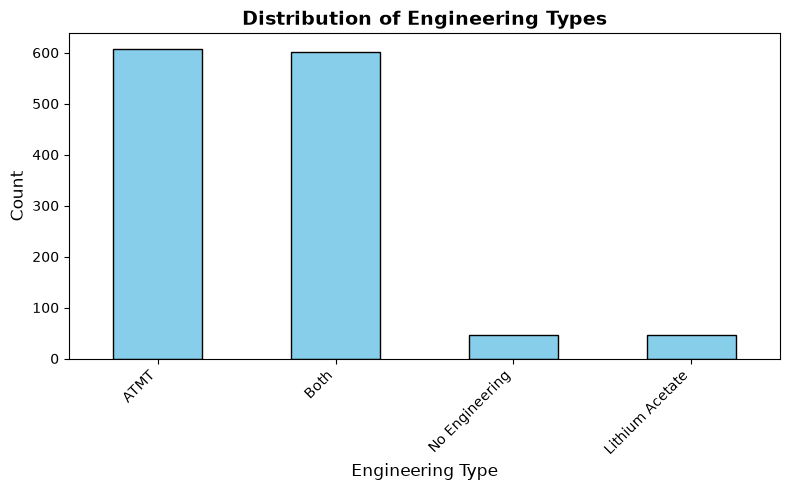

In [8]:
#Plotting how many of each type of engineering we have
counts = df_pivoted_all_proteins['engineering_type'].value_counts()
counts.plot(kind='bar', figsize=(8, 5), color='skyblue', edgecolor='black')
plt.title('Distribution of Engineering Types', fontsize=14, fontweight='bold')
plt.xlabel('Engineering Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [9]:
#Since we will use endogenous proteins as the features, will make a dataframe that only has proteins that include RHOTO in the name
#since that indicates they are from the orgasism we are working with
df_pivoted_Rhodo_proteins = df_pivoted_all_proteins.filter(like='RHOTO')
df_pivoted_Rhodo_proteins[["source_and_sample", "Source_file", "Sample_name", 'strain', 'time', 'ATMT_plasmid', "engineering_type"]] = df_pivoted_all_proteins[[
   "source_and_sample", "Source_file", "Sample_name", 'strain', 'time', 'ATMT_plasmid', "engineering_type"
]]
#Preparing this feature data for later splitting
X = df_pivoted_Rhodo_proteins.drop(['source_and_sample', 'Source_file', 'Sample_name', 'strain', 'time', 'ATMT_plasmid', 'engineering_type'], axis = 1)
#Preparing the first thing to be predicted (engineering type)
y = df_pivoted_Rhodo_proteins.engineering_type

#Preparing the second thing that we will predict (exogenous protein expression)
#First we need to drop proteins that are added in as controls to measure human/system contamination and are not expressed in the samples

drop_cols = [
    "source_and_sample", "Source_file", "Sample_name", 
    "strain", "time", "ATMT_plasmid", "engineering_type", "TRYP_PIG", 'ALBU_BOVIN', 'M7XN52_RHOT1', 'M7Y0N8_RHOT1', 'LYSC_CHICK'
]

non_rhodo_protein_cols = [
    col for col in df_pivoted_all_proteins.columns 
    if col not in drop_cols and "RHOTO" not in col and "HUMAN" not in col
]

y_exogenous = exogenous_sum = df_pivoted_all_proteins[non_rhodo_protein_cols].fillna(0).sum(axis=1)

In [10]:
non_rhodo_protein_cols

['APHA_ECOLI',
 'ERG12_YEAST',
 'ERG13_YEAST',
 'HMDH1_YEAST',
 'MVD1_YEAST',
 'PPB_ECOLI']

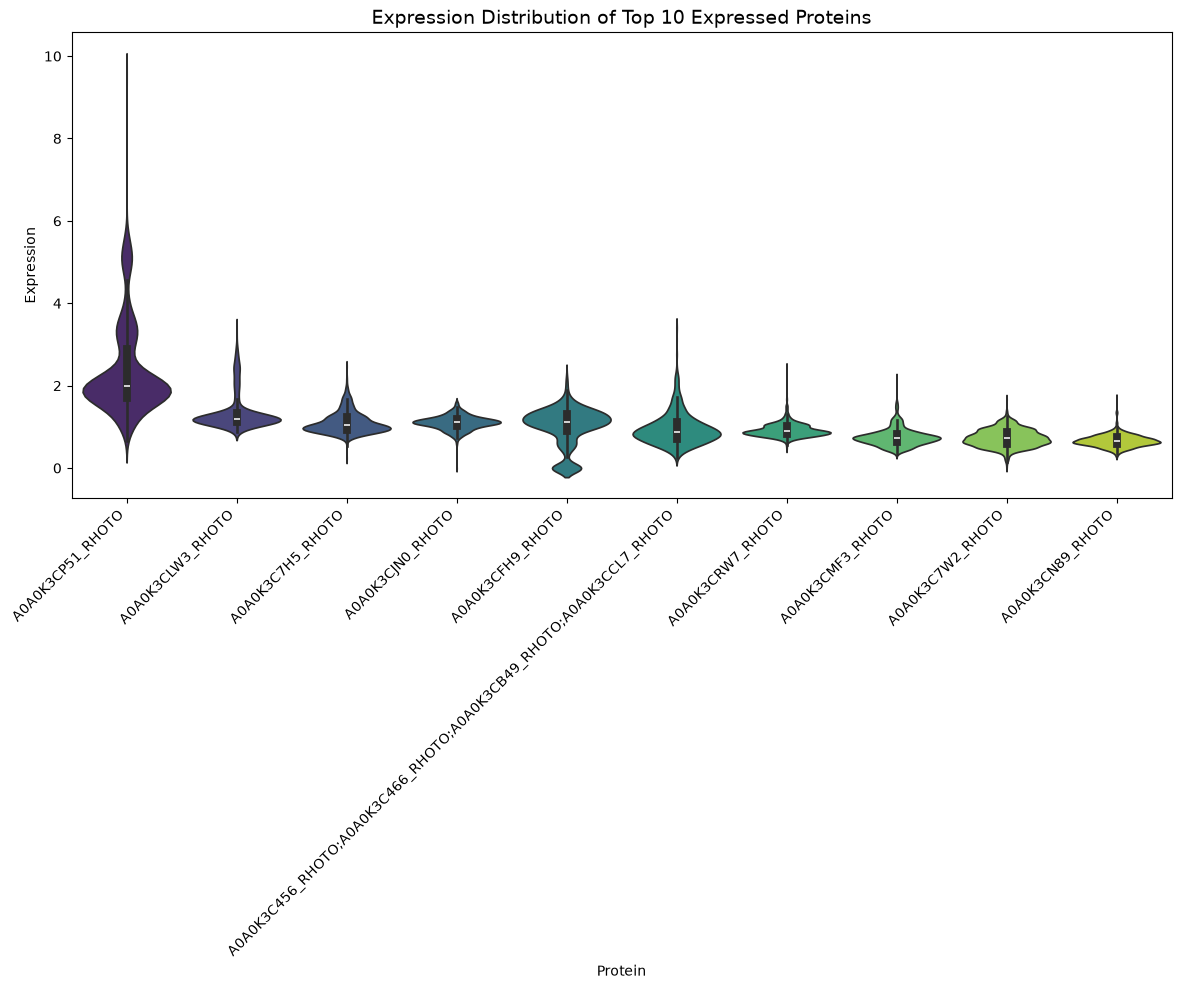

In [11]:
#Going to graph a violin plot of the top 10 expressed proteins to see if there is anything funny going on
top_10_proteins = X.mean().nlargest(10).index
df_top_10 = df_pivoted_Rhodo_proteins[top_10_proteins]
df_long = df_top_10.melt(var_name="Protein", value_name="Expression")

plt.figure(figsize=(12, 10))
sns.violinplot(
    data=df_long,
    x="Protein",
    y="Expression",
    hue="Protein",  # Avoids upcoming palette warning
    palette="viridis",
    legend=False,
)
plt.title("Expression Distribution of Top 10 Expressed Proteins", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

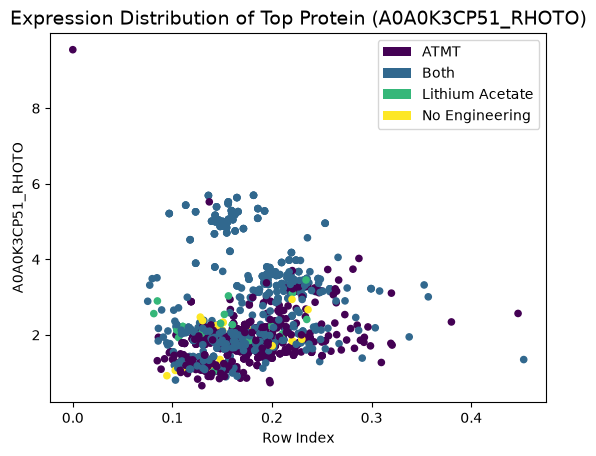

In [12]:
#Plotting a scatter plot of that top hi A0A0K3CP51_RHOTO to see how its distributed across engineering strains

df_pivoted_Rhodo_proteins.plot.scatter(x=1, y='A0A0K3CP51_RHOTO', c='engineering_type')
plt.xlabel('Row Index')
plt.title("Expression Distribution of Top Protein (A0A0K3CP51_RHOTO)", fontsize=14)
plt.show()

In [13]:
#Looking at z-scores across the endogenous proteins
df_zscore = df_pivoted_Rhodo_proteins.select_dtypes(include='number').apply(stats.zscore)
df_zscore
extreme_outliers = (df_zscore > 3).sum().sum()
print(extreme_outliers)
print("Percent of extreme outliers in total data", extreme_outliers/2923568*100)

33871
Percent of extreme outliers in total data 1.1585501004252339


In [14]:
# Evaluate if the z-scores are evenly spread in the dataset using a chi-squared analysis
threshold = 3

outlier_mask = df_zscore.abs() > threshold
outliers_per_sample = outlier_mask.sum(axis=1)
total_outliers = outliers_per_sample.sum()
num_samples = len(outliers_per_sample)

if total_outliers > 0:
    expected_outliers = [total_outliers / num_samples] * num_samples
    
    # Calculate Chi-Square statistic and p-value
    chi2_stat, p_value = stats.chisquare(f_obs=outliers_per_sample, f_exp=expected_outliers)
    
    print(f"Total Outliers Found: {total_outliers}")
    print(f"Chi-Square Statistic: {chi2_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
else:
    print("No outliers detected across any samples.")


Total Outliers Found: 36625
Chi-Square Statistic: 127285.0407
P-value: 0.0000


## Modeling Efforts

### We will first look at modeling if we can classify the different engineering types

In [15]:
#Starting with efforts to see if can classify engineering type, therefore are going to start by using the data with just rhodo proteins.
#Split the data into features we want to use to model and the output we are modeling
X_train, X_test, y_train, y_test = train_test_split(X, y)


In [16]:
#Starting by creating a dummy model
dummy_clf = DummyClassifier().fit(X_train, y_train)
baseline_training_score = dummy_clf.score(X_train, y_train)
baseline_test_score = dummy_clf.score(X_test, y_test)

#Creating a dataframe to start adding the performance metrics to 
model_performance = {
    'Model': [],
    'Train Accuracy': [],
    'Test Accuracy': []
}

model_performance = pd.DataFrame(model_performance)
model_performance.loc[len(model_performance)] = ['Dummy Pipeline', baseline_training_score,baseline_test_score]
model_performance

,Model,Train Accuracy,Test Accuracy
0,Dummy Pipeline,0.47137,0.432515


In [17]:
#Here we will build and test an KNN-nearest neighbors model using a grid search for the best parameters
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
])

knn_param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"],
}

knn_search = GridSearchCV(knn_pipe, knn_param_grid, cv=5, scoring="accuracy", n_jobs=-1)

knn_search.fit(X_train, y_train)




,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__metric': ['euclidean', 'manhattan', ...], 'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"v

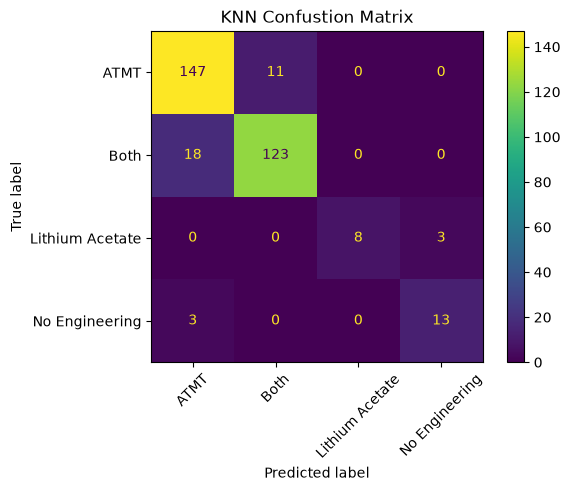

,Model,Train Accuracy,Test Accuracy
0,Dummy Pipeline,0.47137,0.432515
1,KNN Pipeline,1.00000,0.892638


In [18]:
#Determaining accuracy
knn_y_train_pred = knn_search.predict(X_train)
knn_y_test_pred = knn_search.predict(X_test)
knn_y_train_accuracy = accuracy_score(y_train, knn_y_train_pred)
knn_y_test_accuracy = accuracy_score(y_test, knn_y_test_pred)

ConfusionMatrixDisplay.from_predictions(y_test, knn_y_test_pred, xticks_rotation=45)
plt.tight_layout()
plt.title("KNN Confustion Matrix")
plt.show()


#adding values from above to dataframe
model_performance.loc[len(model_performance)] = ['KNN Pipeline', knn_y_train_accuracy, knn_y_test_accuracy]
model_performance

In [19]:
#Here we will build and test a random forrest classifier
rf_pipe = Pipeline([
    ("rf", RandomForestClassifier()),
])

rf_param_grid = {
    "rf__n_estimators": [100, 200, 300, 500],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__max_features": ["sqrt", "log2"],
}

rf_search = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring="accuracy", n_jobs=-1)
rf_search.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [None, 5, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_split': [2, 5, ...], 'rf__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for c

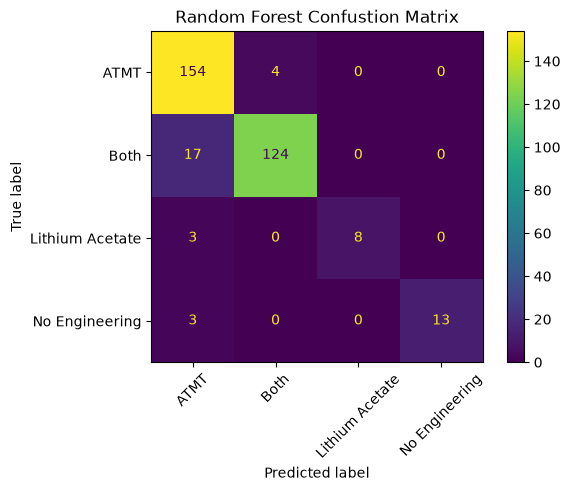

,Model,Train Accuracy,Test Accuracy
0,Dummy Pipeline,0.47137,0.432515
1,KNN Pipeline,1.00000,0.892638
2,Random Forest Pipeline,1.00000,0.917178


In [20]:
#Determain the Accuracy
rf_y_train_pred = rf_search.predict(X_train)
rf_y_test_pred = rf_search.predict(X_test)
rf_y_train_accuracy = accuracy_score(y_train, rf_y_train_pred)
rf_y_test_accuracy = accuracy_score(y_test, rf_y_test_pred)

ConfusionMatrixDisplay.from_predictions(y_test, rf_y_test_pred, xticks_rotation=45)
plt.tight_layout()
plt.title("Random Forest Confustion Matrix")
plt.show()


#add accuracy to accuracy table
model_performance.loc[len(model_performance)] = ['Random Forest Pipeline', rf_y_train_accuracy,rf_y_test_accuracy]
model_performance

In [21]:
#Now we are exploring a decision tree pipeline
dt_pipe = Pipeline([
    ("dt", DecisionTreeClassifier()),
])

dt_param_grid = {
    "dt__max_depth": [None, 3, 5, 10, 20],
    "dt__min_samples_split": [2, 5, 10],
    "dt__min_samples_leaf": [1, 2, 5],
    "dt__criterion": ["gini", "entropy", "log_loss"],
}

dt_search = GridSearchCV(dt_pipe, dt_param_grid, cv=5, scoring="accuracy", n_jobs=-1)
dt_search.fit(X_train, y_train)



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'dt__criterion': ['gini', 'entropy', ...], 'dt__max_depth': [None, 3, ...], 'dt__min_samples_leaf': [1, 2, ...], 'dt__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support 

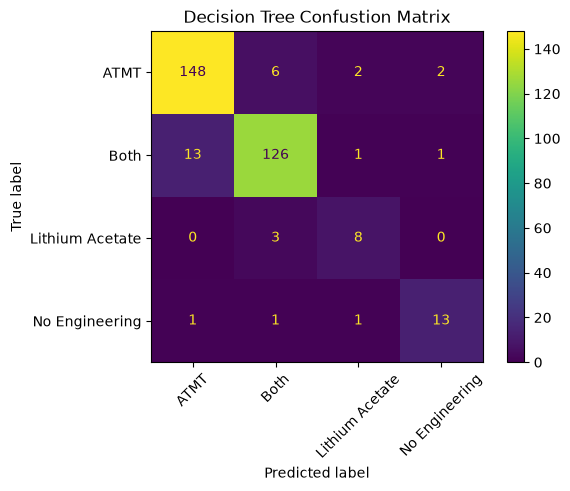

,Model,Train Accuracy,Test Accuracy
0,Dummy Pipeline,0.47137,0.432515
1,KNN Pipeline,1.00000,0.892638
2,Random Forest Pipeline,1.00000,0.917178
3,Decision Tree Pipeline,1.00000,0.904908


In [22]:
#Determain the Accuracy

dt_y_train_pred = dt_search.predict(X_train)
dt_y_test_pred = dt_search.predict(X_test)
dt_y_train_accuracy = accuracy_score(y_train, dt_y_train_pred)
dt_y_test_accuracy = accuracy_score(y_test, dt_y_test_pred)
#add accuracy to accuracy table

ConfusionMatrixDisplay.from_predictions(y_test, dt_y_test_pred, xticks_rotation=45)
plt.tight_layout()
plt.title("Decision Tree Confustion Matrix")
plt.show()

model_performance.loc[len(model_performance)] = ['Decision Tree Pipeline', dt_y_train_accuracy,dt_y_test_accuracy]
model_performance

In [23]:
# This is a little computationally intensive cell, it will take awhile to run
#Since the Random Forest Pipeline is often (although not always) the best want to see if can do some futher optimization
rf_param_dist = [
    {
        "rf__bootstrap": [True],
        "rf__max_samples": [None, 0.6, 0.7, 0.8, 0.9],
        "rf__n_estimators": stats.randint(100, 500),
        "rf__max_depth": [None, 10, 20, 30],
        "rf__class_weight": [None, "balanced", "balanced_subsample"],
    },
    {
        "rf__bootstrap": [False],
        # Exclude max_samples here!
        "rf__n_estimators": stats.randint(100, 500),
        "rf__max_depth": [None, 10, 20, 30],
        "rf__class_weight": [None, "balanced"],
    }
]
# Stratified K-Fold matters here since you likely have uneven
# numbers of samples across your 4 transformation classes
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True)

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=100,           # number of random combinations to try
    cv=cv_strategy,
    scoring="accuracy",  # better than plain accuracy if classes are imbalanced
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)



Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'rf__bootstrap': [True], 'rf__class_weight': [None, 'balanced', ...], 'rf__max_depth': [None, 10, ...], 'rf__max_samples': [None, 0.6, ...], ...}, {'rf__bootstrap': [False], 'rf__class_weight': [None, 'balanced'], 'rf__max_depth': [None, 10, ...], 'rf__n_estimators': <scipy.stats....t 0x164c609d0>}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`

In [24]:
rf_search_y_train_pred = rf_search.predict(X_train)
rf_search_y_test_pred = rf_search.predict(X_test)
rf_search_y_train_accuracy = accuracy_score(y_train, rf_search_y_train_pred)
rf_search_y_test_accuracy = accuracy_score(y_test, rf_search_y_test_pred)

best_rf_pipe = rf_search.best_estimator_
print('The best parameters were:', best_rf_pipe)


best_rf_model = best_rf_pipe.named_steps["rf"]
importances = pd.Series(
    best_rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print('The most influential features were:', importances.head(20))
model_performance.loc[len(model_performance)] = ['Random Forest Boosted Pipeline', rf_search_y_train_accuracy , rf_search_y_test_accuracy]
model_performance

The best parameters were: Pipeline(steps=[('rf',
                 RandomForestClassifier(bootstrap=False, max_depth=10,
                                        n_estimators=248))])
The most influential features were: A0A0K3CRQ8_RHOTO    0.010791
A0A0K3CAL1_RHOTO    0.009938
A0A0K3CK50_RHOTO    0.009679
A0A0K3CIE7_RHOTO    0.008565
A0A0K3CTV3_RHOTO    0.008123
A0A0K3CER3_RHOTO    0.007849
A0A0K3C4H0_RHOTO    0.007745
A0A0K3CB75_RHOTO    0.007018
A0A0K3C8W2_RHOTO    0.006554
A0A0K3CK46_RHOTO    0.006499
A0A0K3CGG0_RHOTO    0.006228
A0A0K3CJA5_RHOTO    0.006223
A0A0K3C8B6_RHOTO    0.006160
A0A0K3CJ95_RHOTO    0.006145
A0A0K3CEQ6_RHOTO    0.005934
A0A0K3CHN4_RHOTO    0.005703
A0A0K3CIC9_RHOTO    0.005612
A0A0K3C4I8_RHOTO    0.005436
A0A0K3CDM7_RHOTO    0.005294
A0A0K3CQR7_RHOTO    0.004844
dtype: float64


,Model,Train Accuracy,Test Accuracy
0,Dummy Pipeline,0.47137,0.432515
1,KNN Pipeline,1.00000,0.892638
2,Random Forest Pipeline,1.00000,0.917178
3,Decision Tree Pipeline,1.00000,0.904908
4,Random Forest Boosted Pipeline,1.00000,0.907975


                 precision    recall  f1-score   support

           ATMT       0.86      0.97      0.91       158
           Both       0.96      0.87      0.91       141
Lithium Acetate       1.00      0.73      0.84        11
 No Engineering       1.00      0.81      0.90        16

       accuracy                           0.91       326
      macro avg       0.96      0.84      0.89       326
   weighted avg       0.91      0.91      0.91       326



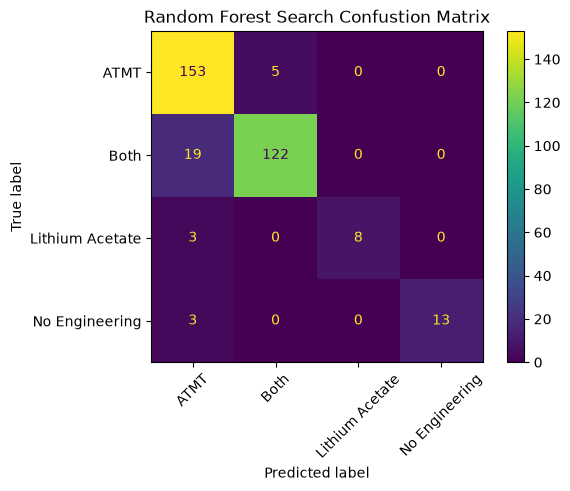

In [25]:
print(classification_report(y_test, rf_search_y_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, rf_search_y_test_pred, xticks_rotation=45)
plt.tight_layout()
plt.title("Random Forest Search Confustion Matrix")
plt.show()

In [27]:
#Note about the interpertation
#all the lithium acetate transformed strains here have a gene knocked out (that therefore would be 0 in the proteomics) protein 415982
#This is likely why the accuracy is so good for identifying lithium acetate transformed strains specifically

#Using proteomics data and a Random Forst model we can make a pretty accurate prediction of how the cells were transformed



## We will next look at if we can predict the total exogenously expressed/ present protein levels from the endogenous protein expression levels

In [31]:
#Splitting the data into a training and test set
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_exogenous)

In [32]:
#Now we will try to do predictions for exogenous protein expression using a simple LinearRegression model
linear_regression = LinearRegression()
linear_regression.fit(X_train2, y_train2)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2242,)","[-0.12,-0.82, 0.44,...,-0.83, 0.56,-1.73]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2242,)","['A0A059XCF6_RHOTO','A0A061AEQ7_RHOTO','A0A061AEZ8_RHOTO',..., 'A0A2T0A5D2_RHOTO','A0A2T0AI07_RHOTO','G1APK3_RHOTO']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,65.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2242
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,594


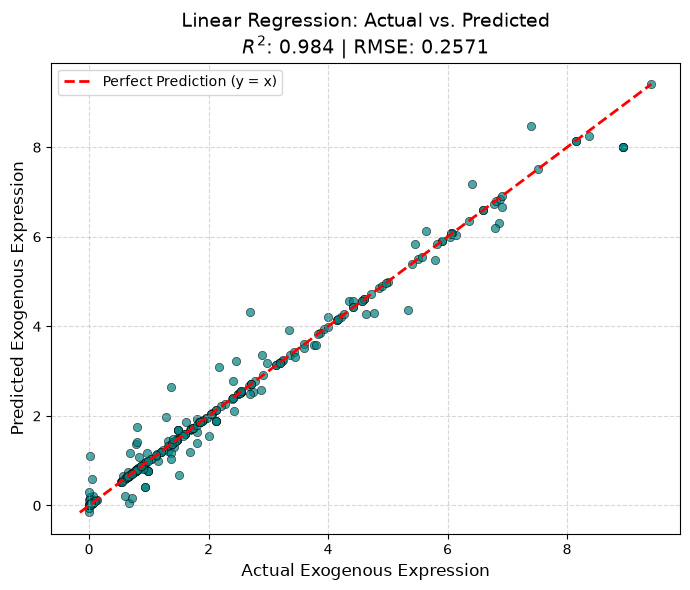

,Model,Train MSE,Test MSE
0,Linear Regression,6.063730e-16,0.066081


In [33]:
lr_y_train_pred = linear_regression.predict(X_train2)
lr_y_test_pred = linear_regression.predict(X_test2)
lr_y_train_mse = mean_squared_error(y_train2, lr_y_train_pred)
lr_y_test_mse = mean_squared_error(y_test2, lr_y_test_pred)

#Going to plot a scatter plot for the best model in one of my runs of actual versus predicted values
r2 = r2_score(y_test2, lr_y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test2, lr_y_test_pred))

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=y_test2, y=lr_y_test_pred, alpha=0.7, edgecolor="k", color="teal"
)

min_val = min(min(y_test2), min(lr_y_test_pred))
max_val = max(max(y_test2), max(lr_y_test_pred))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Perfect Prediction (y = x)",
)

#Formatting
plt.xlabel("Actual Exogenous Expression", fontsize=12)
plt.ylabel("Predicted Exogenous Expression", fontsize=12)
plt.title(
    f"Linear Regression: Actual vs. Predicted\n$R^2$: {r2:.3f} | RMSE: {rmse:.4f}",
    fontsize=14,
)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#Creating performance table to track all the models MSE
model_performance2 = {
    'Model': [],
    'Train MSE': [],
    'Test MSE': []
}

#Adding MSE to performance table
model_performance2 = pd.DataFrame(model_performance2)
model_performance2.loc[len(model_performance2)] = ['Linear Regression', lr_y_train_mse,lr_y_test_mse]
model_performance2

In [34]:
#Now we will try a lasso model
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, alphas=100, max_iter=10000))
])

lasso_pipeline.fit(X_train2, y_train2)




,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2242,)","['A0A059XCF6_RHOTO','A0A061AEQ7_RHOTO','A0A061AEZ8_RHOTO',..., 'A0A2T0A5D2_RHOTO','A0A2T0AI07_RHOTO','G1APK3_RHOTO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2242
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


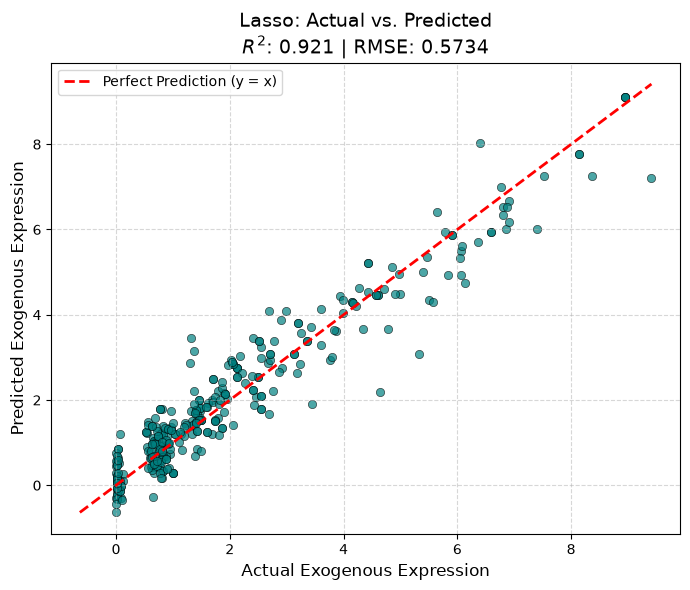

,Model,Train MSE,Test MSE
0,Linear Regression,6.063730e-16,0.066081
1,Lasso,2.350935e-01,0.328783


In [35]:
lasso_y_train_pred = lasso_pipeline.predict(X_train2)
lasso_y_test_pred = lasso_pipeline.predict(X_test2)
lasso_y_train_mse = mean_squared_error(y_train2, lasso_y_train_pred)
lasso_y_test_mse = mean_squared_error(y_test2, lasso_y_test_pred)

#Going to plot a scatter plot for the best model in one of my runs of actual versus predicted values
r2 = r2_score(y_test2, lasso_y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test2, lasso_y_test_pred))

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=y_test2, y=lasso_y_test_pred, alpha=0.7, edgecolor="k", color="teal"
)

#adding reference line
min_val = min(min(y_test2), min(lasso_y_test_pred))
max_val = max(max(y_test2), max(lasso_y_test_pred))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Perfect Prediction (y = x)",
)

#Formatting
plt.xlabel("Actual Exogenous Expression", fontsize=12)
plt.ylabel("Predicted Exogenous Expression", fontsize=12)
plt.title(
    f"Lasso: Actual vs. Predicted\n$R^2$: {r2:.3f} | RMSE: {rmse:.4f}",
    fontsize=14,
)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#Adding performance to performance table
model_performance2.loc[len(model_performance2)] = ['Lasso', lasso_y_train_mse,lasso_y_test_mse]
model_performance2

In [36]:
feature_cols = [col for col in df_pivoted_Rhodo_proteins.columns if col not in drop_cols]

# 1. Extract the fitted Lasso model and feature names
fitted_lasso = lasso_pipeline.named_steps['lasso']

# 2. Build a summary DataFrame of all features and their coefficients
protein_coefs = pd.DataFrame({
    'Protein': feature_cols,
    'Coefficient': fitted_lasso.coef_
})

# 3. Filter for non-zero coefficients (kept proteins)
kept_proteins = protein_coefs[protein_coefs['Coefficient'] != 0].copy()

# Add absolute value column to easily sort by impact magnitude
kept_proteins['Abs_Coefficient'] = kept_proteins['Coefficient'].abs()
kept_proteins = kept_proteins.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

# Output the results
print(f"Optimal Alpha: {fitted_lasso.alpha_:.6f}")
print(f"Total input proteins : {len(feature_cols)}")
print(f"Proteins kept        : {len(kept_proteins)}\n")

print("--- Kept Proteins and Their Weights ---")
print(kept_proteins.to_string(index=False))

Optimal Alpha: 0.030235
Total input proteins : 2242
Proteins kept        : 186

--- Kept Proteins and Their Weights ---
                                                            Protein  Coefficient
                                                   A0A0K3CNT0_RHOTO     0.427615
                                                   A0A0K3CN30_RHOTO    -0.315877
                                                   A0A0K3CCM0_RHOTO    -0.272805
                                                   A0A0K3CR23_RHOTO    -0.248549
                                                   A0A0K3CSJ7_RHOTO     0.247505
                                                   A0A0K3CDN2_RHOTO     0.224584
                                                   A0A0K3CCF3_RHOTO    -0.200252
A0A0K3C456_RHOTO;A0A0K3C466_RHOTO;A0A0K3CB49_RHOTO;A0A0K3CCL7_RHOTO    -0.184651
                                                   A0A0K3CHN4_RHOTO     0.182729
                                                   A0A0K3CDI2_RHOTO   

<Figure size 800x500 with 0 Axes>

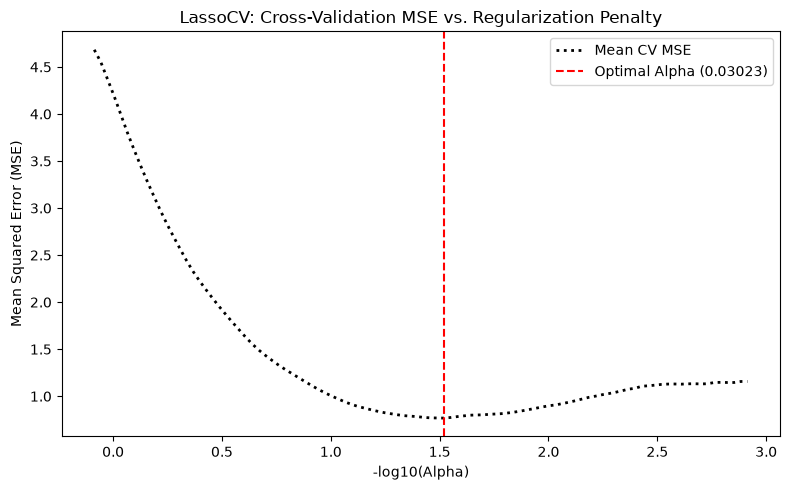

In [37]:
plt.figure(figsize=(8, 5))

# Compute mean MSE across CV folds for each alpha tested
fitted_lasso = lasso_pipeline.named_steps['lasso']
m_log_alphas = -np.log10(fitted_lasso.alphas_)
cv_mse_mean = fitted_lasso.mse_path_.mean(axis=-1)

plt.figure(figsize=(8, 5))
plt.plot(m_log_alphas, cv_mse_mean, 'k:', label='Mean CV MSE', linewidth=2)
plt.axvline(-np.log10(fitted_lasso.alpha_), linestyle='--', color='red', 
            label=f'Optimal Alpha ({fitted_lasso.alpha_:.5f})')

plt.xlabel('-log10(Alpha)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('LassoCV: Cross-Validation MSE vs. Regularization Penalty')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
lasso_pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, alphas=2, max_iter=10000))
])

lasso_pipeline2.fit(X_train2, y_train2)

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.946017e-01, tolerance: 3.540e-01
  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2242,)","['A0A059XCF6_RHOTO','A0A061AEQ7_RHOTO','A0A061AEZ8_RHOTO',..., 'A0A2T0A5D2_RHOTO','A0A2T0AI07_RHOTO','G1APK3_RHOTO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2242
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


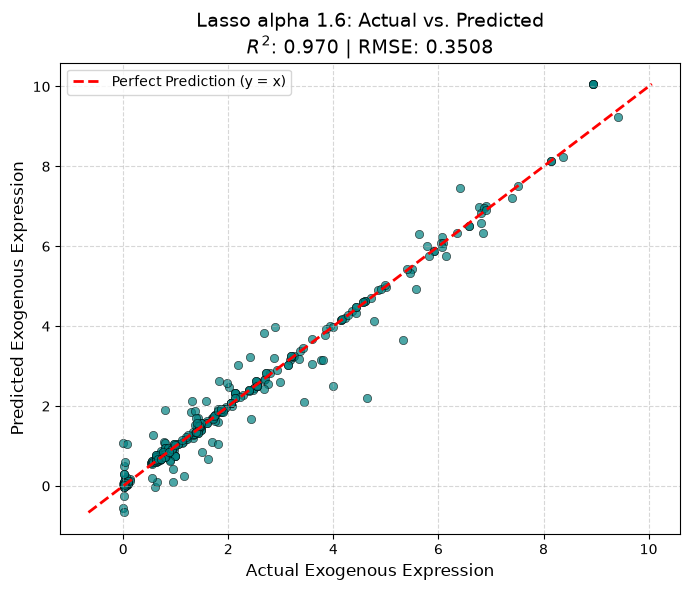

,Model,Train MSE,Test MSE
0,Linear Regression,6.063730e-16,0.066081
1,Lasso,2.350935e-01,0.328783
2,Lasso alpha = 1.6,2.161317e-03,0.123040


In [39]:
lasso2_y_train_pred = lasso_pipeline2.predict(X_train2)
lasso2_y_test_pred = lasso_pipeline2.predict(X_test2)
lasso2_y_train_mse = mean_squared_error(y_train2, lasso2_y_train_pred)
lasso2_y_test_mse = mean_squared_error(y_test2, lasso2_y_test_pred)

#Going to plot a scatter plot for the best model in one of my runs of actual versus predicted values
r2 = r2_score(y_test2, lasso2_y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test2, lasso2_y_test_pred))

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=y_test2, y=lasso2_y_test_pred, alpha=0.7, edgecolor="k", color="teal"
)

min_val = min(min(y_test2), min(lasso2_y_test_pred))
max_val = max(max(y_test2), max(lasso2_y_test_pred))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Perfect Prediction (y = x)",
)

#Formatting
plt.xlabel("Actual Exogenous Expression", fontsize=12)
plt.ylabel("Predicted Exogenous Expression", fontsize=12)
plt.title(
    f"Lasso alpha 1.6: Actual vs. Predicted\n$R^2$: {r2:.3f} | RMSE: {rmse:.4f}",
    fontsize=14,
)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#Adding msa to performance table
model_performance2.loc[len(model_performance2)] = ['Lasso alpha = 1.6', lasso2_y_train_mse,lasso2_y_test_mse]
model_performance2

In [40]:
#Trying an elastic_pipe as well
elastic_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.99], cv=5, max_iter=10000))
])
elastic_pipe.fit(X_train2, y_train2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('elastic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2242,)","['A0A059XCF6_RHOTO','A0A061AEQ7_RHOTO','A0A061AEZ8_RHOTO',..., 'A0A2T0A5D2_RHOTO','A0A2T0AI07_RHOTO','G1APK3_RHOTO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2242
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


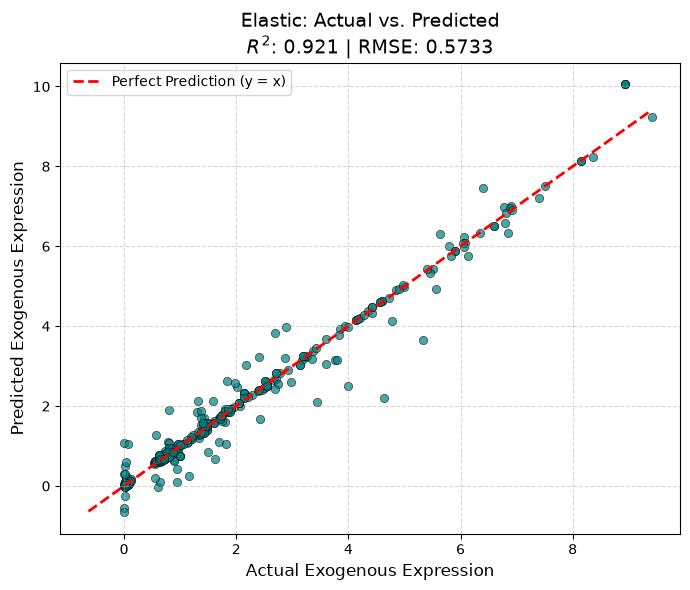

,Model,Train MSE,Test MSE
0,Linear Regression,6.063730e-16,0.066081
1,Lasso,2.350935e-01,0.328783
2,Lasso alpha = 1.6,2.161317e-03,0.123040
3,Elastic Pipeline,2.352019e-01,0.328722


In [41]:
elastic_y_train_pred = elastic_pipe.predict(X_train2)
elastic_y_test_pred = elastic_pipe.predict(X_test2)
elastic_y_train_mse = mean_squared_error(y_train2, elastic_y_train_pred)
elastic_y_test_mse = mean_squared_error(y_test2, elastic_y_test_pred)

#Going to plot a scatter plot for the best model in one of my runs of actual versus predicted values
r2 = r2_score(y_test2, elastic_y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test2, elastic_y_test_pred))

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=y_test2, y=lasso2_y_test_pred, alpha=0.7, edgecolor="k", color="teal"
)

min_val = min(min(y_test2), min(elastic_y_test_pred))
max_val = max(max(y_test2), max(elastic_y_test_pred))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    lw=2,
    label="Perfect Prediction (y = x)",
)

#Formatting
plt.xlabel("Actual Exogenous Expression", fontsize=12)
plt.ylabel("Predicted Exogenous Expression", fontsize=12)
plt.title(
    f"Elastic: Actual vs. Predicted\n$R^2$: {r2:.3f} | RMSE: {rmse:.4f}",
    fontsize=14,
)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#Adding MSE to performance table
model_performance2.loc[len(model_performance2)] = ['Elastic Pipeline', elastic_y_train_mse,elastic_y_test_mse]
model_performance2

## Some interpertation

 All of the classification models tested for identifying engineering type far outperformed the dummy classifier and are all ~90% accurate. The performance of each is relative to eachother is somewhat variable depending on how the data randomly gets split into the train and test sets. To really identify the best model for predicting engineering type, it would be great to test the models on a validation data set that was not used to build these models. It would also be good to test them on a set of proteomics data from completely unrelated strains that were generated through the same methods.

 For predicting the total exogenous protein expression, the Linear Regression model far outperforms the rest with fairly good accurate perdictions on the outcome. This model would also benefit from validation using data from unrelated strains.

 It would be very interesting after further validation to look more into the proteins that are most important in the models. At a quick glance many of those proteins appear to be related to protein translation, which makes sense since we are generally increasing the protein translation need by engineering strains with high expressing pathways.